**Problem Statement**:Every retail and e-commerce company — from Walmart and Amazon to D-Mart and Flipkart — lives and dies by one question: "How much of each product will we sell next month, and will we have enough stock to meet that demand?" Getting this wrong in either direction costs crores — overstock wastes storage and capital, understock loses sales and customers.
This is not a beginner classification problem. This is a multi-layered, real industry problem that requires you to work with time-series data (data ordered by date, not rows of independent customers), build and compare multiple forecasting models, detect anomalies in sales patterns, segment products by demand behavior, and deliver a working interactive dashboard that a business manager could open on Monday morning and make stocking decisions from.
You will touch Time Series Analysis, Machine Learning, Forecasting, Anomaly Detection, Customer/Product Segmentation, and Deployment — all in one project. This is the kind of system that data science teams at mid-to-large companies actually build and maintain.


**TASK-1**:Data Loading, Merging & Deep Exploration

Importing all the required libraries:-

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

from prophet import Prophet

from xgboost import XGBRegressor

import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

Loading dataset taken from kaggle:https://www.kaggle.com/datasets/rohitsahoo/sales-forecasting, and the supplementary dataset taken again from kaggle:https://www.kaggle.com/datasets/gregorut/videogamesales.

In [ ]:
df = pd.read_csv('/train.csv')
dp = pd.read_csv('/vgsales.csv')
df.head(10)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
5,6,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600
6,7,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800
7,8,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520
8,9,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040
9,10,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000


In [ ]:
dp.head(10)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006.0,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [ ]:
df[["Order Date", "Ship Date"]].head()

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


In [ ]:
print(df.head())
print(df.columns)

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520   
1       2  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520   
2       3  CA-2017-138688 2017-06-12 2017-06-16    Second Class    DV-13045   
3       4  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335   
4       5  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Category Sub-Ca

Addressing the Columns to our required data.

In [ ]:

df["Year"] = df["Order Date"].dt.year

df["Month"] = df["Order Date"].dt.month


df["Month Name"] = df["Order Date"].dt.month_name()


df["Week"] = df["Order Date"].dt.isocalendar().week.astype(int)


df["Day of Week"] = df["Order Date"].dt.day_name()


df["Quarter"] = df["Order Date"].dt.quarter


def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week,Day of Week,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,Wednesday,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,Wednesday,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,Monday,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,Tuesday,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,Tuesday,4,Autumn


In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
df.duplicated().sum()

np.int64(0)

**Now to answer the questions asked.**

Which product category generates the highest total revenue? To answer this we are using the sum method to get the result.

In [ ]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


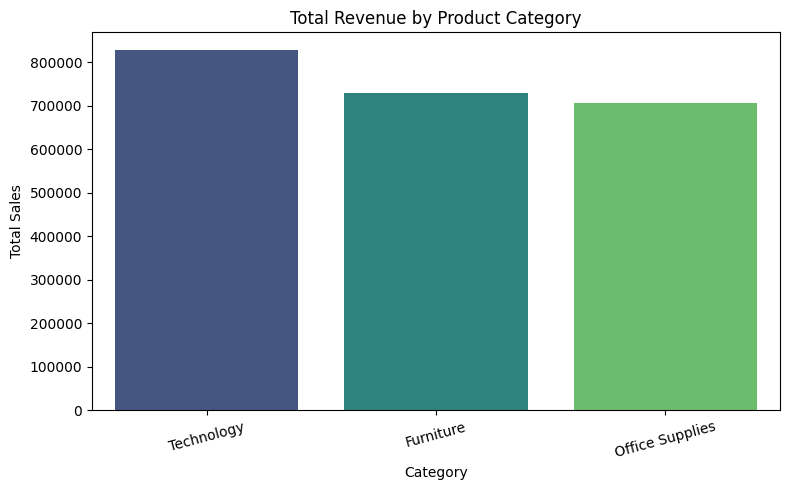

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values,
    palette="viridis"
)

plt.title("Total Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig("SalesForecasting_Mrinal/charts/category_sales.png", dpi=300)

plt.show()

Which region has the most consistent sales growth?

In [ ]:
region_year = (
    df.groupby(["Year", "Region"])["Sales"]
      .sum()
      .reset_index()
)

region_year.head()

,Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724


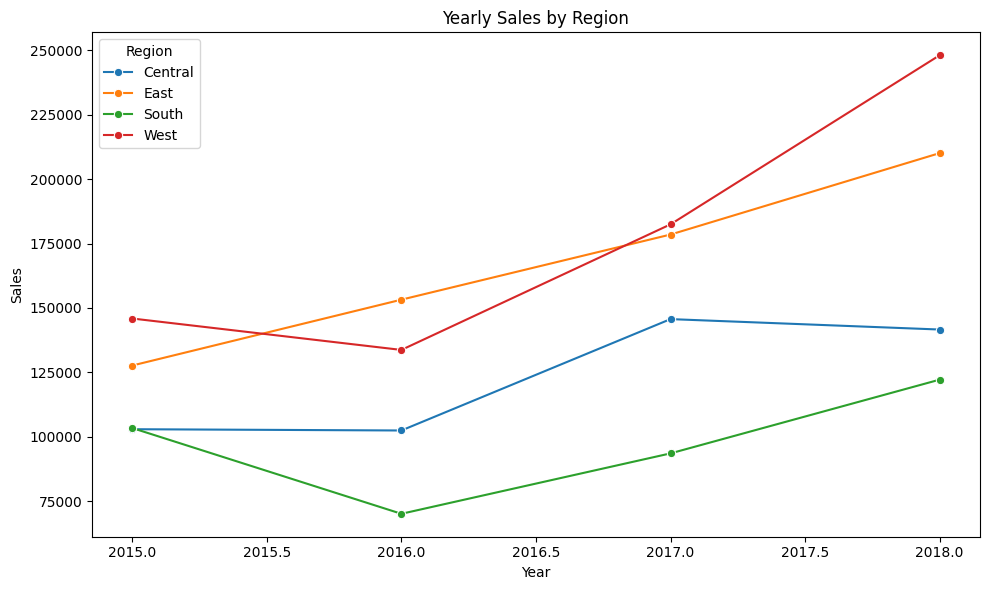

In [ ]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=region_year,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o"
)

plt.title("Yearly Sales by Region")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.tight_layout()
plt.savefig("SalesForecasting_Mrinal/charts/region_growth.png", dpi=300)

plt.show()

Average shipping time by region

In [ ]:
shipping_region = (
    df.groupby("Region")["Shipping Days"]
      .mean()
      .sort_values()
)

print(shipping_region)

Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Days, dtype: float64


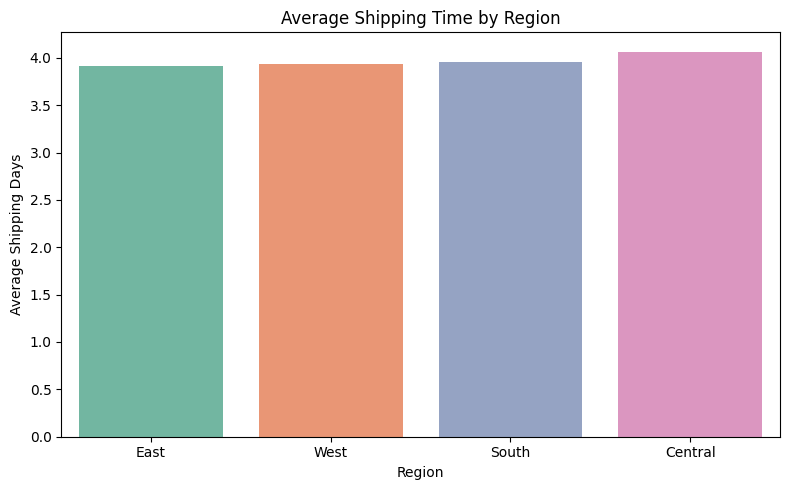

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=shipping_region.index,
    y=shipping_region.values,
    palette="Set2"
)

plt.title("Average Shipping Time by Region")
plt.xlabel("Region")
plt.ylabel("Average Shipping Days")

plt.tight_layout()
plt.savefig("SalesForecasting_Mrinal/charts/shipping_by_region.png", dpi=300)

plt.show()

Are there months that consistently spike across all years?

In [ ]:
monthly = (
    df.groupby(["Year", "Month"])["Sales"]
      .sum()
      .reset_index()
)

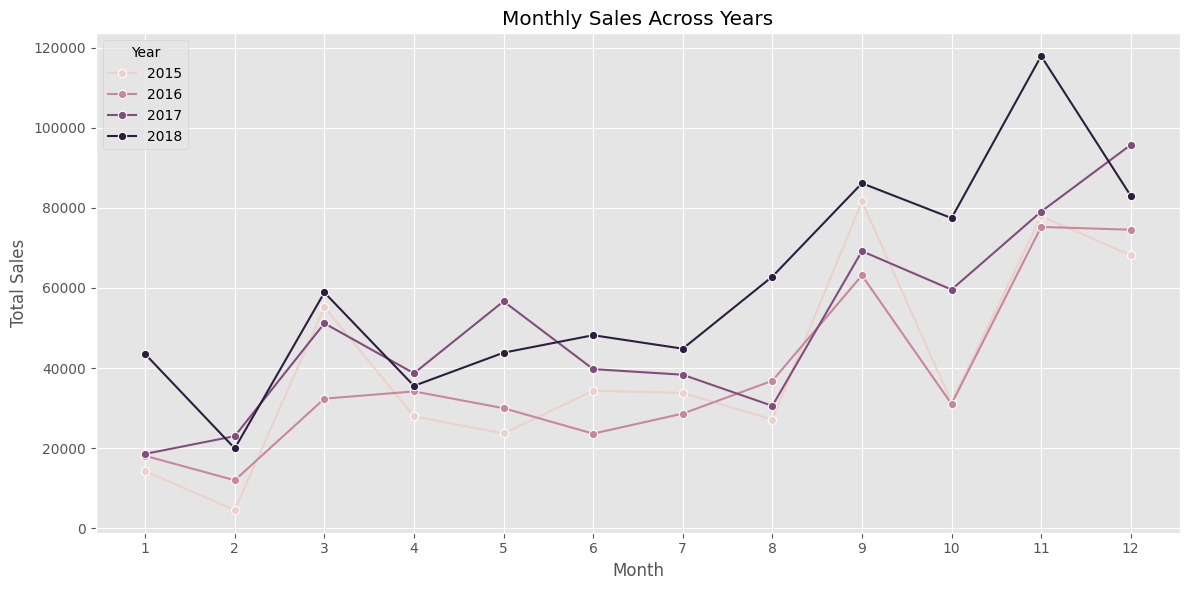

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly,
    x="Month",
    y="Sales",
    hue="Year",
    marker="o"
)

plt.title("Monthly Sales Across Years")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(range(1,13))

plt.grid(True)

plt.tight_layout()
plt.savefig("SalesForecasting_Mrinal/charts/monthly_sales_by_year.png", dpi=300)

plt.show()

TASK-2:Time Series Analysis & Decomposition

In [ ]:
monthly_sales = (
    df.set_index("Order Date")
      .resample("ME")["Sales"]
      .sum()
)

monthly_sales.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


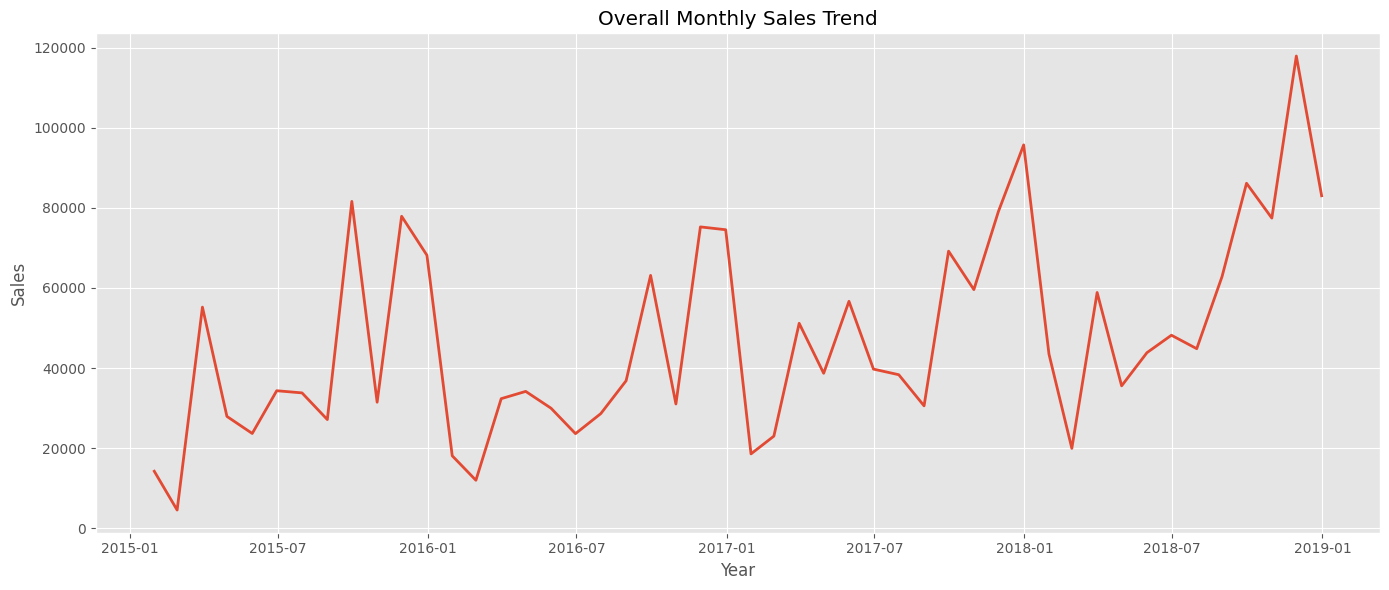

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(monthly_sales, linewidth=2)

plt.title("Overall Monthly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "SalesForecasting_Mrinal/charts/monthly_sales_trend.png",
    dpi=300
)

plt.show()

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

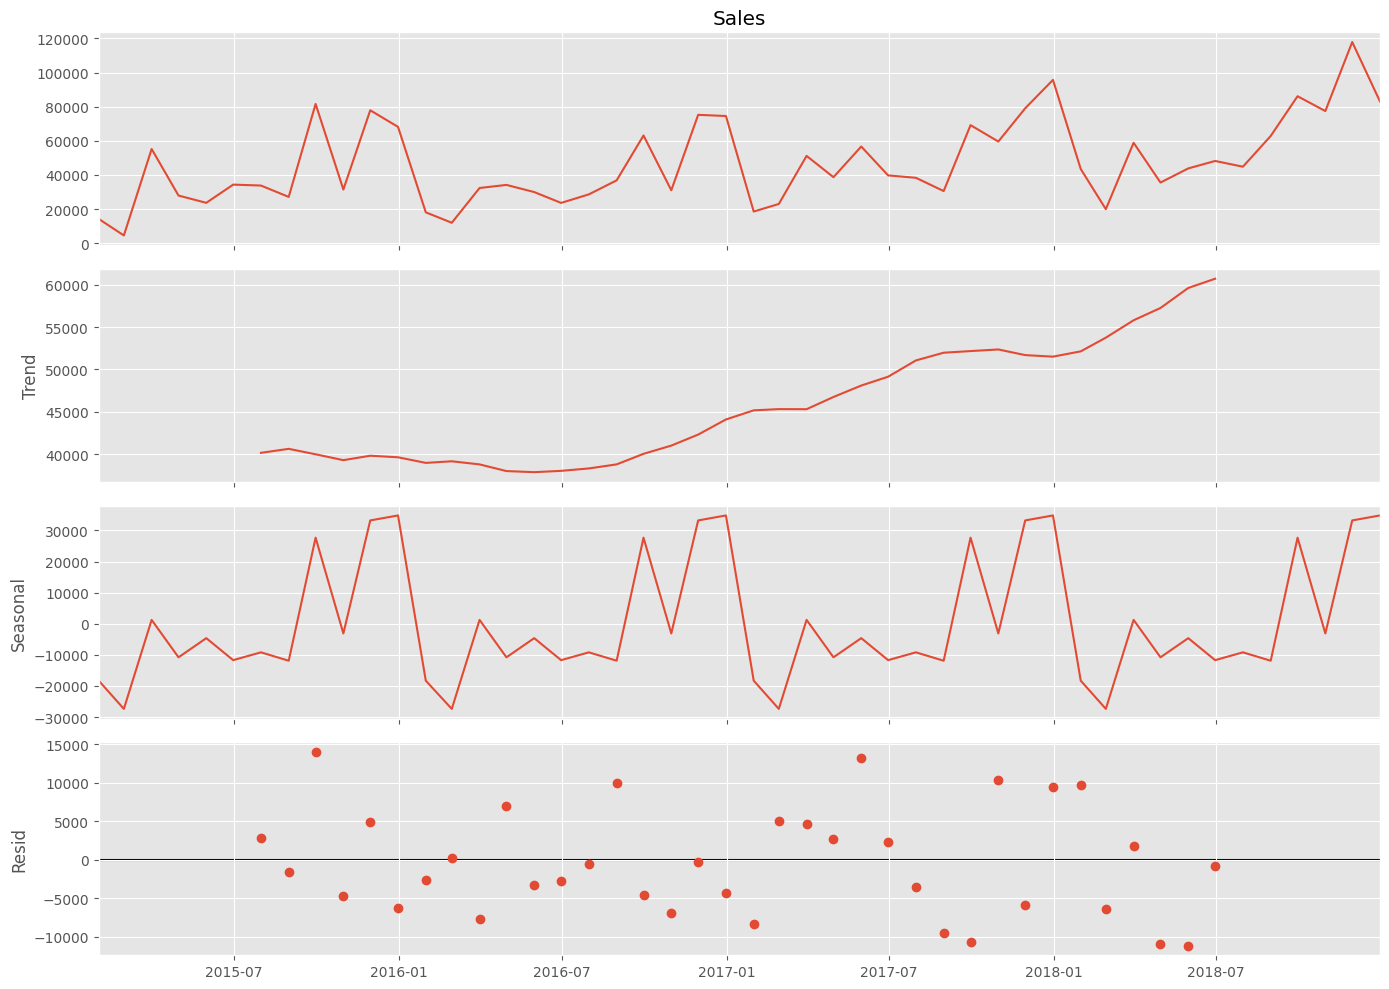

In [ ]:
fig = decomposition.plot()

fig.set_size_inches(14,10)

plt.tight_layout()

plt.savefig(
    "SalesForecasting_Mrinal/charts/time_series_decomposition.png",
    dpi=300
)

plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

In [ ]:
result = adfuller(monthly_sales)

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")

for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623
Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


In [ ]:
monthly_diff = monthly_sales.diff().dropna()

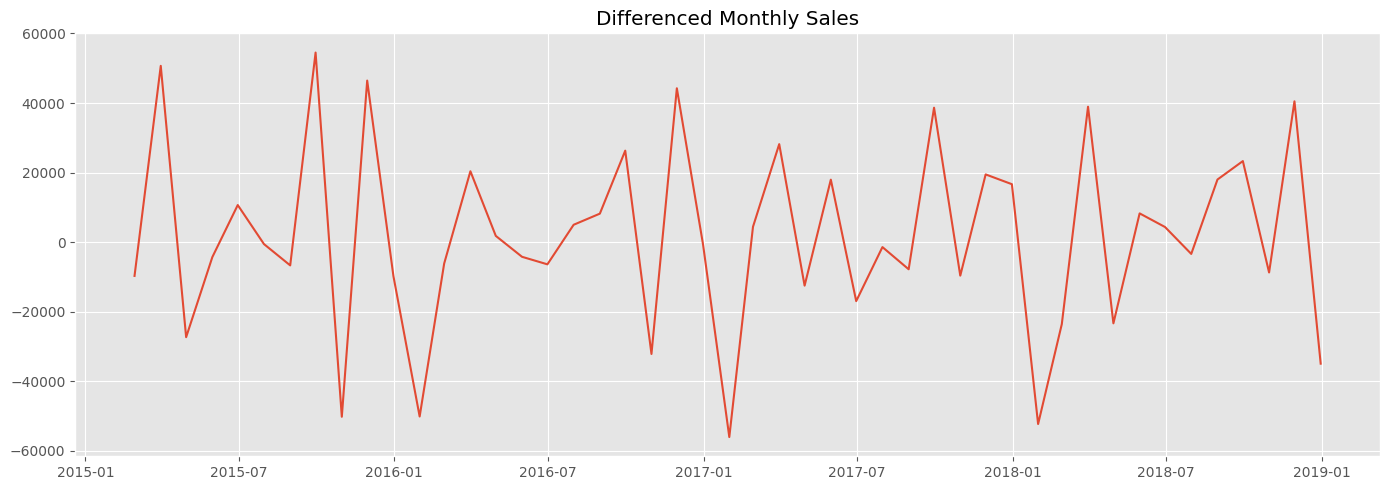

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(monthly_diff)

plt.title("Differenced Monthly Sales")

plt.grid(True)

plt.tight_layout()

plt.show()

In [ ]:
result_diff = adfuller(monthly_diff)

print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])

for key, value in result_diff[4].items():
    print(f"{key}: {value}")

ADF Statistic: -8.727061830353268
p-value: 3.2669175472796045e-14
1%: -3.626651907578875
5%: -2.9459512825788754
10%: -2.6116707716049383


**TASK-3**:Sales Forecasting using 3 Different Models


In [ ]:
#Train-Test-Split

train = monthly_sales[:-3]
test = monthly_sales[-3:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

print("\nTest Data:")
print(test)

Training observations: 45
Testing observations: 3

Test Data:
Order Date
2018-10-31     77448.1312
2018-11-30    117938.1550
2018-12-31     83030.3888
Freq: ME, Name: Sales, dtype: float64


MODEL-1:SARIMA

Installing and importing SARIMA

In [ ]:
!pip install statsmodels

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
sarima = SARIMAX(
    train,
    order=(1,0,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_model = sarima.fit()

print(sarima_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -203.681
Date:                            Sat, 11 Jul 2026   AIC                            417.362
Time:                                    09:00:51   BIC                            422.084
Sample:                                01-31-2015   HQIC                           418.161
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9830      0.034     28.593      0.000       0.916       1.050
ma.L1         -0.9959      0.293   

In [ ]:
forecast = sarima_model.get_forecast(steps=3)

sarima_pred = forecast.predicted_mean

conf_int = forecast.conf_int()

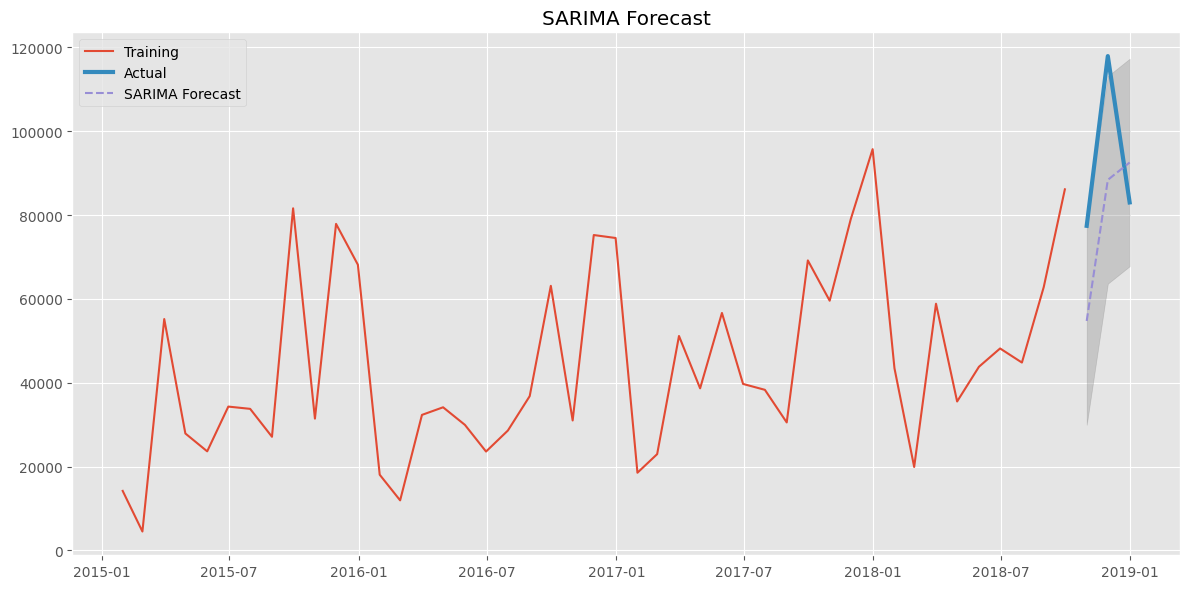

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train, label="Training")

plt.plot(test.index, test,
         label="Actual",
         linewidth=3)

plt.plot(test.index,
         sarima_pred,
         label="SARIMA Forecast",
         linestyle="--")

plt.fill_between(
    conf_int.index,
    conf_int.iloc[:,0],
    conf_int.iloc[:,1],
    color="gray",
    alpha=0.3
)

plt.legend()

plt.title("SARIMA Forecast")

plt.tight_layout()

plt.savefig(
    "SalesForecasting_Mrinal/charts/sarima_forecast.png",
    dpi=300
)

plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

import numpy as np

sarima_mae = mean_absolute_error(test, sarima_pred)

sarima_rmse = np.sqrt(
    mean_squared_error(test, sarima_pred)
)

sarima_mape = mean_absolute_percentage_error(
    test,
    sarima_pred
)

print("MAE :", sarima_mae)
print("RMSE:", sarima_rmse)
print("MAPE:", sarima_mape)

MAE : 20581.00014223503
RMSE: 22191.26609266294
MAPE: 0.21935472982348106


In [ ]:
sarima_results = {
    "Model":"SARIMA",
    "MAE":sarima_mae,
    "RMSE":sarima_rmse,
    "MAPE":sarima_mape,
    "Month1":sarima_pred.iloc[0],
    "Month2":sarima_pred.iloc[1],
    "Month3":sarima_pred.iloc[2]
}
print(sarima_results)

{'Model': 'SARIMA', 'MAE': 20581.00014223503, 'RMSE': np.float64(22191.26609266294), 'MAPE': 0.21935472982348106, 'Month1': np.float64(54758.511838385064), 'Month2': np.float64(88412.59554883285), 'Month3': np.float64(92558.21041392299)}


MODEL-2:Prophet

Installing Prophet and importing Prophet.

In [ ]:
!pip install prophet

In [ ]:
from prophet import Prophet

In [ ]:
prophet_df = monthly_sales.reset_index()
prophet_df.columns = ["ds", "y"]

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [ ]:
train_prophet = prophet_df.iloc[:-3]
test_prophet = prophet_df.iloc[-3:]

In [ ]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(train_prophet)

In [ ]:
future = model.make_future_dataframe(periods=3, freq="ME")

forecast = model.predict(future)

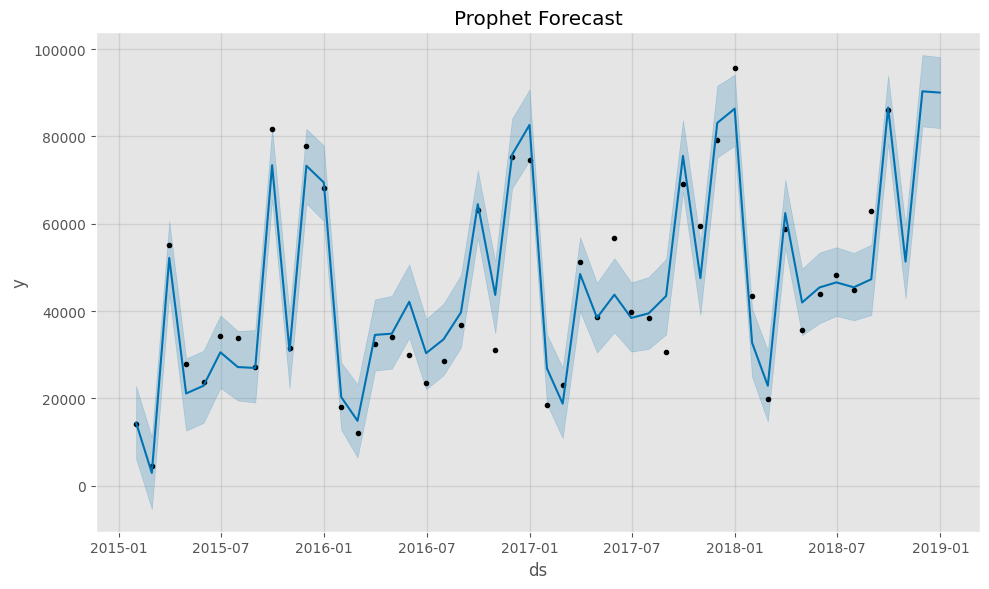

In [ ]:
fig = model.plot(forecast)

plt.title("Prophet Forecast")

plt.tight_layout()

plt.savefig(
    "SalesForecasting_Mrinal/charts/prophet_forecast.png",
    dpi=300
)

plt.show()

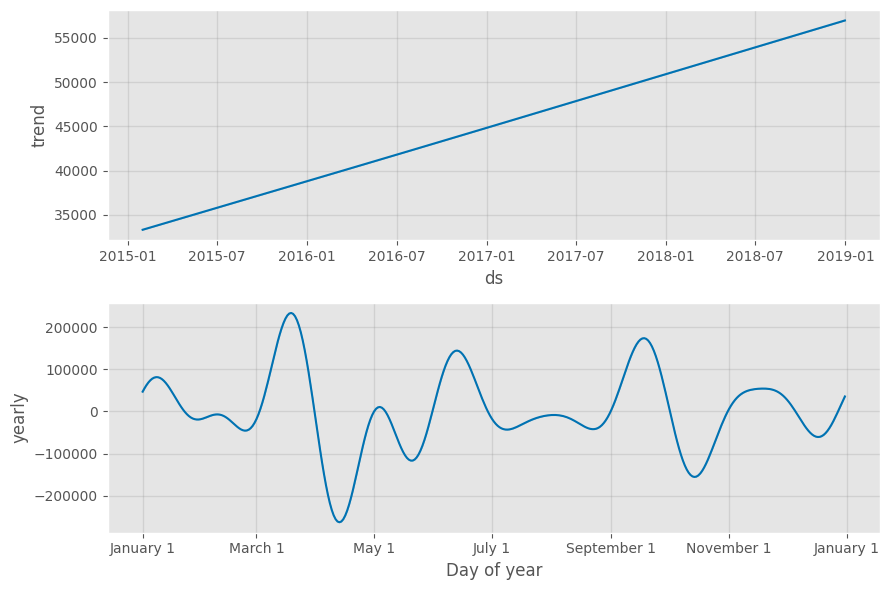

In [ ]:
fig2 = model.plot_components(forecast)

plt.tight_layout()

plt.savefig(
    "SalesForecasting_Mrinal/charts/prophet_components.png",
    dpi=300
)

plt.show()

In [ ]:
prophet_pred = forecast.tail(3)["yhat"].values

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import numpy as np

prophet_mae = mean_absolute_error(
    test_prophet["y"],
    prophet_pred
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        test_prophet["y"],
        prophet_pred
    )
)

prophet_mape = mean_absolute_percentage_error(
    test_prophet["y"],
    prophet_pred
)

print("MAE :", prophet_mae)
print("RMSE:", prophet_rmse)
print("MAPE:", prophet_mape)

MAE : 20250.794427610937
RMSE: 22318.41136551923
MAPE: 0.21864628287701435


In [ ]:
prophet_results = {
    "Model": "Prophet",
    "MAE": prophet_mae,
    "RMSE": prophet_rmse,
    "MAPE": prophet_mape,
    "Month1": prophet_pred[0],
    "Month2": prophet_pred[1],
    "Month3": prophet_pred[2]
}

print(prophet_results)

{'Model': 'Prophet', 'MAE': 20250.794427610937, 'RMSE': np.float64(22318.41136551923), 'MAPE': 0.21864628287701435, 'Month1': np.float64(51318.94381151383), 'Month2': np.float64(90325.65473580032), 'Month3': np.float64(90041.08443014696)}


MODEL-3:XGBoost

Importing XGBoost.

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)
import numpy as np

In [ ]:
ts = monthly_sales.to_frame()
ts.columns = ["Sales"]

ts.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


In [ ]:
ts["Lag1"] = ts["Sales"].shift(1)
ts["Lag2"] = ts["Sales"].shift(2)
ts["Lag3"] = ts["Sales"].shift(3)

In [ ]:
ts["RollingMean3"] = ts["Sales"].rolling(3).mean()

In [ ]:
ts["Month"] = ts.index.month
ts["Quarter"] = ts.index.quarter
ts["Year"] = ts.index.year

In [ ]:
def season(month):
    if month in [12,1,2]:
        return 0
    elif month in [3,4,5]:
        return 1
    elif month in [6,7,8]:
        return 2
    else:
        return 3

ts["Season"] = ts["Month"].apply(season)

In [ ]:
ts = ts.dropna()

ts.head()

,Sales,Lag1,Lag2,Lag3,RollingMean3,Month,Quarter,Year,Season
Order Date,,,,,,,,,
2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,2015,1
2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,2015,1
2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,2015,2
2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,2015,2
2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,2015,2


In [ ]:
X = ts.drop("Sales", axis=1)

y = ts["Sales"]

In [ ]:
X_train = X.iloc[:-3]
X_test = X.iloc[-3:]

y_train = y.iloc[:-3]
y_test = y.iloc[-3:]

In [ ]:
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgb_pred = xgb.predict(X_test)

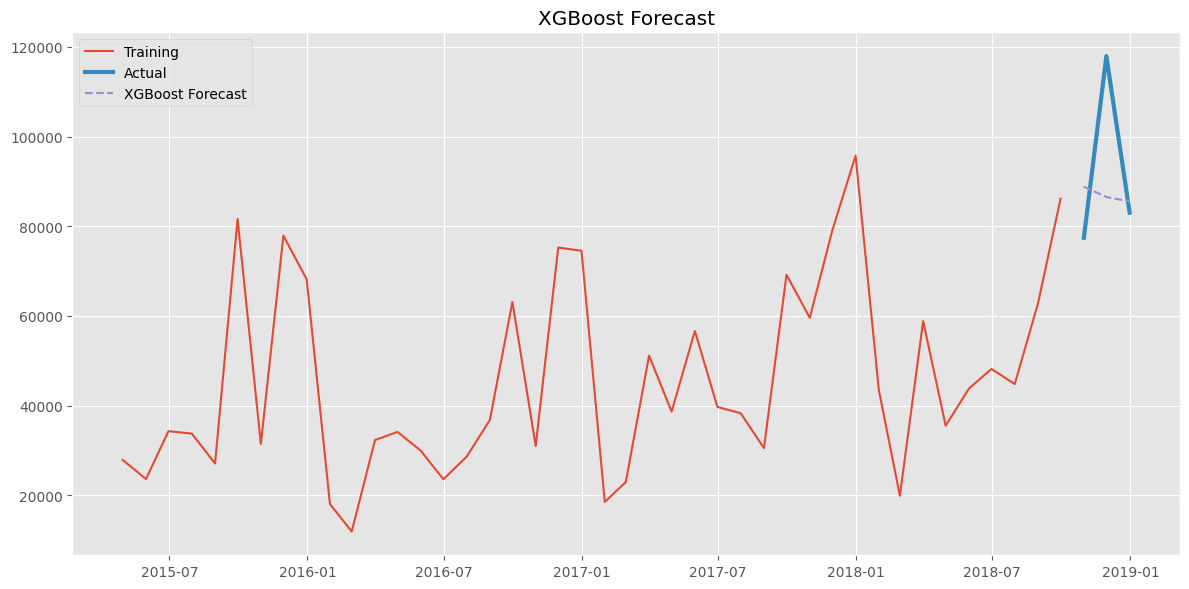

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    y_train.index,
    y_train,
    label="Training"
)

plt.plot(
    y_test.index,
    y_test,
    label="Actual",
    linewidth=3
)

plt.plot(
    y_test.index,
    xgb_pred,
    "--",
    label="XGBoost Forecast"
)

plt.legend()

plt.title("XGBoost Forecast")

plt.tight_layout()

plt.savefig(
    "SalesForecasting_Mrinal/charts/xgboost_forecast.png",
    dpi=300
)

plt.show()

In [ ]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_pred
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)

xgb_mape = mean_absolute_percentage_error(
    y_test,
    xgb_pred
)

print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("MAPE:", xgb_mape)

MAE : 15101.823645833332
RMSE: 19347.993700874787
MAPE: 0.1478430489595137


In [ ]:
xgb_results = {
    "Model":"XGBoost",
    "MAE":xgb_mae,
    "RMSE":xgb_rmse,
    "MAPE":xgb_mape,
    "Month1":xgb_pred[0],
    "Month2":xgb_pred[1],
    "Month3":xgb_pred[2]
}

print(xgb_results)

{'Model': 'XGBoost', 'MAE': 15101.823645833332, 'RMSE': np.float64(19347.993700874787), 'MAPE': 0.1478430489595137, 'Month1': np.float32(88832.3), 'Month2': np.float32(86518.805), 'Month3': np.float32(85532.34)}


MODEL COMPARISION

In [ ]:
comparison = pd.DataFrame([
    sarima_results,
    prophet_results,
    xgb_results
])

comparison

,Model,MAE,RMSE,MAPE,Month1,Month2,Month3
0,SARIMA,20581.000142,22191.266093,0.219355,54758.511838,88412.595549,92558.210414
1,Prophet,20250.794428,22318.411366,0.218646,51318.943812,90325.654736,90041.084430
2,XGBoost,15101.823646,19347.993701,0.147843,88832.296875,86518.804688,85532.343750


In [ ]:
best_model = comparison.sort_values("RMSE").iloc[0]

print(best_model)

Model      XGBoost
MAE       15101.82
RMSE      19347.99
MAPE          0.15
Month1     88832.3
Month2     86518.8
Month3    85532.34
Name: 2, dtype: object


**TASK-4**: Product Category & Region Level Forecasting


In [ ]:
from xgboost import XGBRegressor
import pandas as pd
import numpy as np

def forecast_segment(segment_df):
    """
    Forecast the next 3 months for a given category or region.
    """

    # Monthly sales
    monthly = (
        segment_df.set_index("Order Date")
                  .resample("ME")["Sales"]
                  .sum()
                  .to_frame(name="Sales")
    )

    # Lag features
    monthly["Lag1"] = monthly["Sales"].shift(1)
    monthly["Lag2"] = monthly["Sales"].shift(2)
    monthly["Lag3"] = monthly["Sales"].shift(3)

    # Rolling mean
    monthly["RollingMean3"] = monthly["Sales"].rolling(3).mean()

    # Calendar features
    monthly["Month"] = monthly.index.month
    monthly["Quarter"] = monthly.index.quarter
    monthly["Year"] = monthly.index.year

    # Season
    monthly["Season"] = monthly["Month"].apply(
        lambda x: 0 if x in [12,1,2]
        else 1 if x in [3,4,5]
        else 2 if x in [6,7,8]
        else 3
    )

    monthly = monthly.dropna()

    X = monthly.drop("Sales", axis=1)
    y = monthly["Sales"]

    model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    model.fit(X, y)

    # ---------- Recursive Forecast ----------
    history = monthly.copy()

    forecasts = []

    for _ in range(3):

        last_date = history.index[-1] + pd.offsets.MonthEnd()

        lag1 = history.iloc[-1]["Sales"]
        lag2 = history.iloc[-2]["Sales"]
        lag3 = history.iloc[-3]["Sales"]

        rolling = history["Sales"].tail(3).mean()

        row = pd.DataFrame({
            "Lag1":[lag1],
            "Lag2":[lag2],
            "Lag3":[lag3],
            "RollingMean3":[rolling],
            "Month":[last_date.month],
            "Quarter":[last_date.quarter],
            "Year":[last_date.year],
            "Season":[
                0 if last_date.month in [12,1,2]
                else 1 if last_date.month in [3,4,5]
                else 2 if last_date.month in [6,7,8]
                else 3
            ]
        })

        pred = model.predict(row)[0]

        forecasts.append(pred)

        history.loc[last_date] = [
            pred,
            lag1,
            lag2,
            lag3,
            rolling,
            last_date.month,
            last_date.quarter,
            last_date.year,
            row["Season"].iloc[0]
        ]

    return forecasts

In [ ]:
furniture_forecast = forecast_segment(
    df[df["Category"]=="Furniture"]
)

technology_forecast = forecast_segment(
    df[df["Category"]=="Technology"]
)

office_forecast = forecast_segment(
    df[df["Category"]=="Office Supplies"]
)

In [ ]:
west_forecast = forecast_segment(
    df[df["Region"]=="West"]
)

east_forecast = forecast_segment(
    df[df["Region"]=="East"]
)

In [ ]:
forecast_table = pd.DataFrame({

    "Month":[1,2,3],

    "Furniture":furniture_forecast,

    "Technology":technology_forecast,

    "Office Supplies":office_forecast,

    "West":west_forecast,

    "East":east_forecast

})

forecast_table

,Month,Furniture,Technology,Office Supplies,West,East
0,1,9466.079102,18509.605469,26028.476562,11772.905273,25929.318359
1,2,7667.970703,23088.421875,26033.179688,14123.892578,25807.322266
2,3,16338.311523,20517.648438,29547.033203,21674.242188,28589.169922


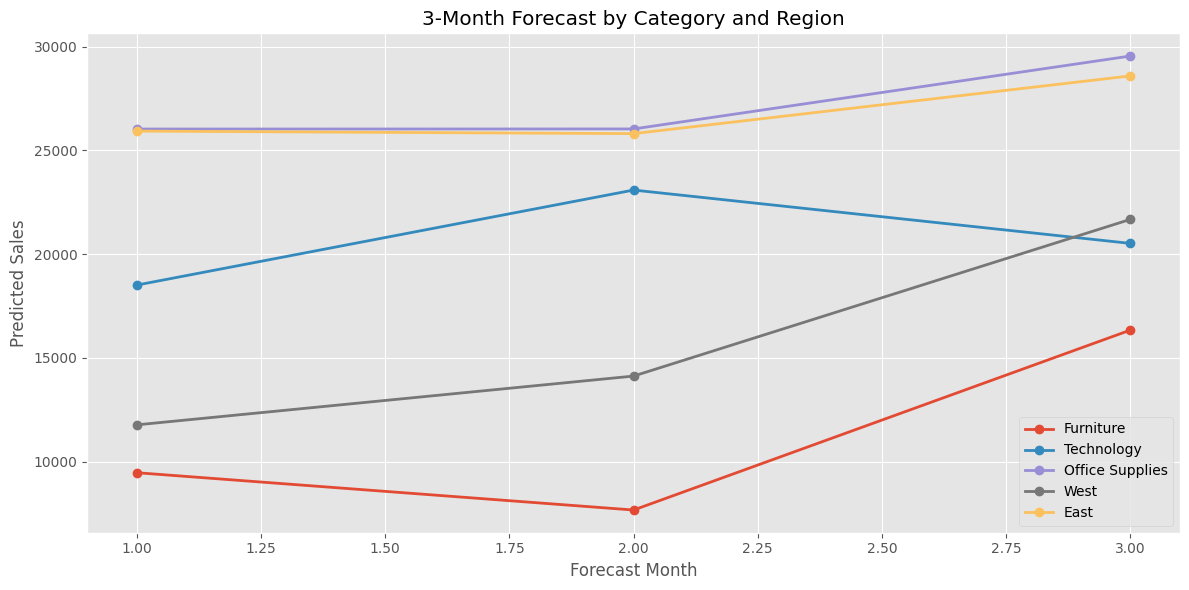

In [ ]:
plt.figure(figsize=(12,6))

for col in forecast_table.columns[1:]:
    plt.plot(
        forecast_table["Month"],
        forecast_table[col],
        marker="o",
        linewidth=2,
        label=col
    )

plt.title("3-Month Forecast by Category and Region")

plt.xlabel("Forecast Month")

plt.ylabel("Predicted Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "SalesForecasting_Mrinal/charts/task4_forecasts.png",
    dpi=300
)

plt.show()

In [ ]:
growth = {}

for col in forecast_table.columns[1:]:
    growth[col] = forecast_table[col].iloc[-1] - forecast_table[col].iloc[0]

growth_df = (
    pd.DataFrame.from_dict(
        growth,
        orient="index",
        columns=["Growth"]
    )
    .sort_values("Growth", ascending=False)
)

print(growth_df)

                      Growth
West             9901.336914
Furniture        6872.232422
Office Supplies  3518.556641
East             2659.851562
Technology       2008.042969


**TASK-5**:Anomaly Detection in Sales Data


In [ ]:
weekly_sales = (
    df.set_index("Order Date")
      .resample("W")["Sales"]
      .sum()
      .to_frame(name="Sales")
)

weekly_sales.head()

,Sales
Order Date,
2015-01-04,304.508
2015-01-11,4619.108
2015-01-18,4130.533
2015-01-25,3092.544
2015-02-01,2527.914


In [ ]:
from sklearn.ensemble import IsolationForest

In [ ]:
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["Isolation"] = iso.fit_predict(
    weekly_sales[["Sales"]]
)

In [ ]:
weekly_sales["Anomaly"] = (
    weekly_sales["Isolation"] == -1
)

In [ ]:
weekly_sales["Anomaly"] = (
    weekly_sales["Isolation"] == -1
)

In [ ]:
weekly_sales[weekly_sales["Anomaly"]]

,Sales,Isolation,Anomaly
Order Date,,,
2015-01-04,304.508,-1,True
2015-02-08,968.534,-1,True
2015-02-22,224.912,-1,True
2015-03-22,37703.665,-1,True
2015-07-19,1387.686,-1,True
2015-09-13,29959.137,-1,True
2016-01-24,358.522,-1,True
2017-12-17,25449.800,-1,True
2018-11-04,29017.467,-1,True


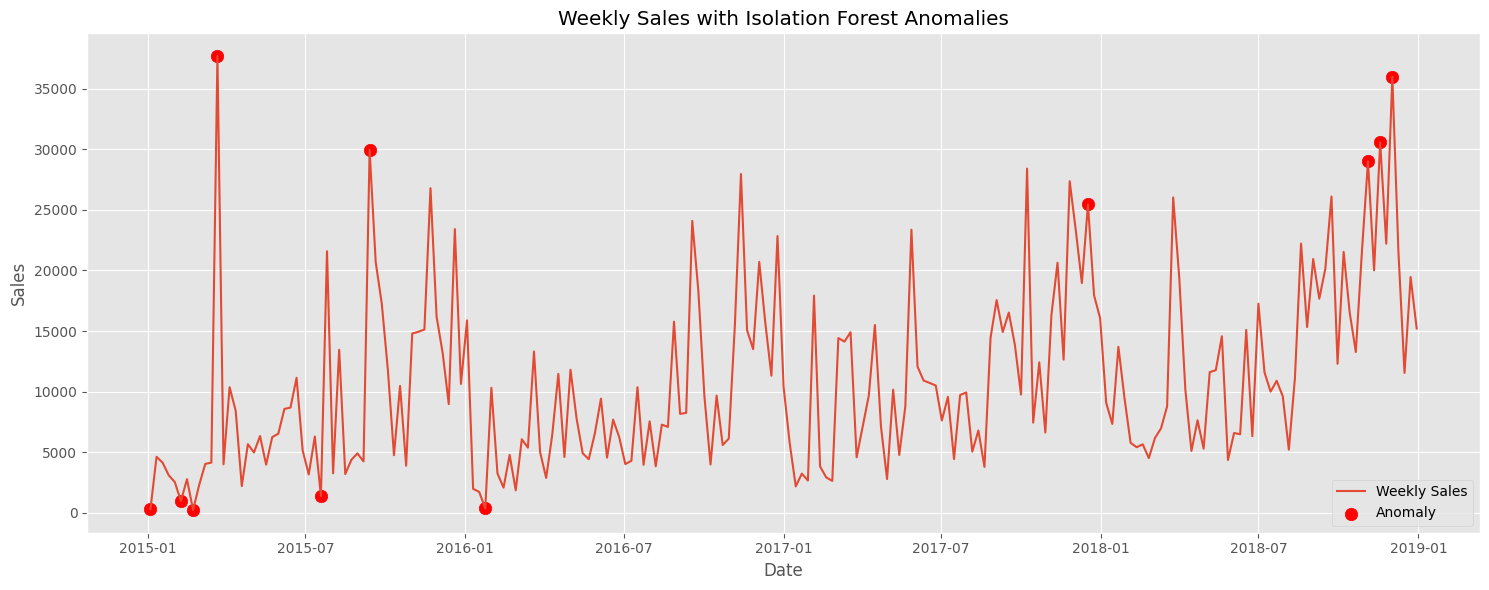

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales.index,
    weekly_sales["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    weekly_sales.index[weekly_sales["Anomaly"]],
    weekly_sales["Sales"][weekly_sales["Anomaly"]],
    color="red",
    s=80,
    label="Anomaly"
)

plt.title("Weekly Sales with Isolation Forest Anomalies")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.tight_layout()

plt.savefig(
    "SalesForecasting_Mrinal/charts/isolation_forest.png",
    dpi=300
)

plt.show()

In [ ]:
weekly_sales["RollingMean"] = (
    weekly_sales["Sales"]
    .rolling(8)
    .mean()
)

weekly_sales["RollingStd"] = (
    weekly_sales["Sales"]
    .rolling(8)
    .std()
)

In [ ]:
weekly_sales["ZScore"] = (
    weekly_sales["Sales"] -
    weekly_sales["RollingMean"]
) / weekly_sales["RollingStd"]

In [ ]:
weekly_sales["Z_Anomaly"] = (
    weekly_sales["ZScore"].abs() > 2
)

In [ ]:
weekly_sales[
    weekly_sales["Z_Anomaly"]
]

,Sales,Isolation,Anomaly,RollingMean,RollingStd,ZScore,Z_Anomaly
Order Date,,,,,,,
2015-03-22,37703.665,-1,True,6832.006500,12546.138409,2.460650,True
2015-07-26,21590.080,1,False,8245.428325,6246.129535,2.136467,True
2016-08-28,15773.478,1,False,7515.302525,4020.682890,2.053924,True
2016-09-18,24095.960,1,False,10251.475400,6524.009519,2.122082,True
2017-05-28,23367.662,1,False,10265.959125,6524.022836,2.008225,True
2018-03-25,26029.904,1,False,8660.308925,7131.467537,2.435627,True


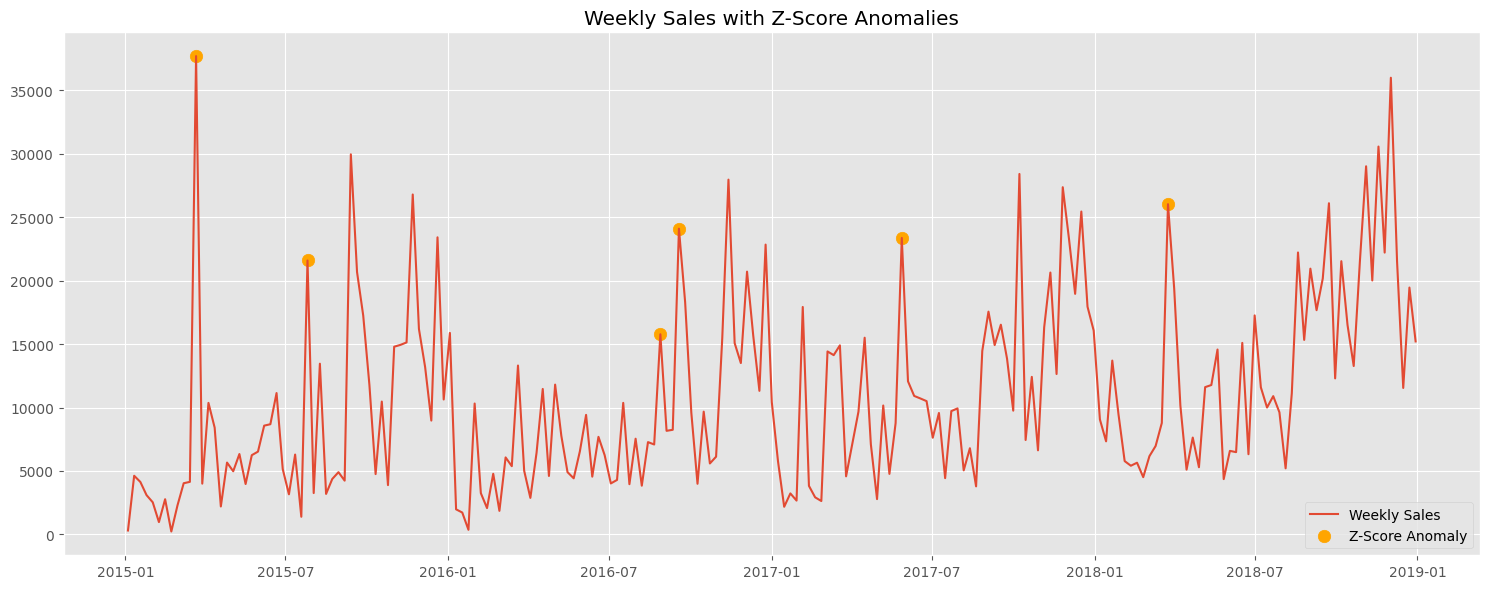

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales.index,
    weekly_sales["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    weekly_sales.index[weekly_sales["Z_Anomaly"]],
    weekly_sales["Sales"][weekly_sales["Z_Anomaly"]],
    color="orange",
    s=80,
    label="Z-Score Anomaly"
)

plt.legend()

plt.title("Weekly Sales with Z-Score Anomalies")

plt.tight_layout()

plt.savefig(
    "SalesForecasting_Mrinal/charts/zscore_anomalies.png",
    dpi=300
)

plt.show()

In [ ]:
comparison = weekly_sales[
    ["Sales", "Anomaly", "Z_Anomaly"]
]

comparison.head()

,Sales,Anomaly,Z_Anomaly
Order Date,,,
2015-01-04,304.508,True,False
2015-01-11,4619.108,False,False
2015-01-18,4130.533,False,False
2015-01-25,3092.544,False,False
2015-02-01,2527.914,False,False


In [ ]:
print("Isolation Forest:", weekly_sales["Anomaly"].sum())

print("Z-Score:", weekly_sales["Z_Anomaly"].sum())

Isolation Forest: 11
Z-Score: 6


In [ ]:
both = weekly_sales[
    weekly_sales["Anomaly"] &
    weekly_sales["Z_Anomaly"]
]

both

,Sales,Isolation,Anomaly,RollingMean,RollingStd,ZScore,Z_Anomaly
Order Date,,,,,,,
2015-03-22,37703.665,-1,True,6832.0065,12546.138409,2.46065,True


In [ ]:
print("Isolation Forest:", weekly_sales["Anomaly"].sum())
print("Z-Score:", weekly_sales["Z_Anomaly"].sum())

Isolation Forest: 11
Z-Score: 6


In [ ]:
weekly_sales[
    weekly_sales["Anomaly"] |
    weekly_sales["Z_Anomaly"]
]

,Sales,Isolation,Anomaly,RollingMean,RollingStd,ZScore,Z_Anomaly
Order Date,,,,,,,
2015-01-04,304.508,-1,True,NaN,NaN,NaN,False
2015-02-08,968.534,-1,True,NaN,NaN,NaN,False
2015-02-22,224.912,-1,True,2329.888375,1676.932120,-1.255254,False
2015-03-22,37703.665,-1,True,6832.006500,12546.138409,2.460650,True
2015-07-19,1387.686,-1,True,6362.072450,3153.431979,-1.577452,False
2015-07-26,21590.080,1,False,8245.428325,6246.129535,2.136467,True
2015-09-13,29959.137,-1,True,10618.766938,10172.926399,1.901161,False
2016-01-24,358.522,-1,True,9517.331763,8020.219353,-1.141965,False
2016-08-28,15773.478,1,False,7515.302525,4020.682890,2.053924,True


**TASK-6**: Product Demand Segmentation using Clustering


In [ ]:
subcat = df.groupby(["Sub-Category", "Year"]).agg(
    TotalSales=("Sales", "sum"),
    AvgOrderValue=("Sales", "mean")
).reset_index()

subcat.head()

,Sub-Category,Year,TotalSales,AvgOrderValue
0,Accessories,2015,23766.396,168.556000
1,Accessories,2016,40443.970,245.114970
2,Accessories,2017,41735.364,226.822630
3,Accessories,2018,58240.970,218.951015
4,Appliances,2015,15160.715,164.790380


In [ ]:
total_sales = (
    df.groupby("Sub-Category")["Sales"]
      .sum()
)

In [ ]:
avg_order = (
    df.groupby("Sub-Category")["Sales"]
      .mean()
)

In [ ]:
monthly_subcat = (
    df.groupby([
        "Sub-Category",
        pd.Grouper(key="Order Date", freq="ME")
    ])["Sales"]
    .sum()
    .reset_index()
)

volatility = (
    monthly_subcat
    .groupby("Sub-Category")["Sales"]
    .std()
)

In [ ]:
yearly_sales = (
    df.groupby(["Sub-Category", "Year"])["Sales"]
      .sum()
      .unstack()
)

In [ ]:
growth = (
    (yearly_sales.iloc[:, -1] - yearly_sales.iloc[:, 0])
    / yearly_sales.iloc[:, 0]
) * 100

In [ ]:
cluster_df = pd.DataFrame({

    "TotalSales": total_sales,

    "GrowthRate": growth,

    "Volatility": volatility,

    "AverageOrderValue": avg_order

})

cluster_df = cluster_df.fillna(0)

cluster_df.head()

,TotalSales,GrowthRate,Volatility,AverageOrderValue
Sub-Category,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175
Appliances,104618.4030,165.242912,1821.621539,227.926804
Art,26705.4100,49.649531,330.488343,34.019631
Binders,200028.7850,65.778638,3848.223648,134.067550
Bookcases,113813.1987,49.846598,2220.405080,503.598224


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled = scaler.fit_transform(cluster_df)

In [ ]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled)

    wcss.append(model.inertia_)

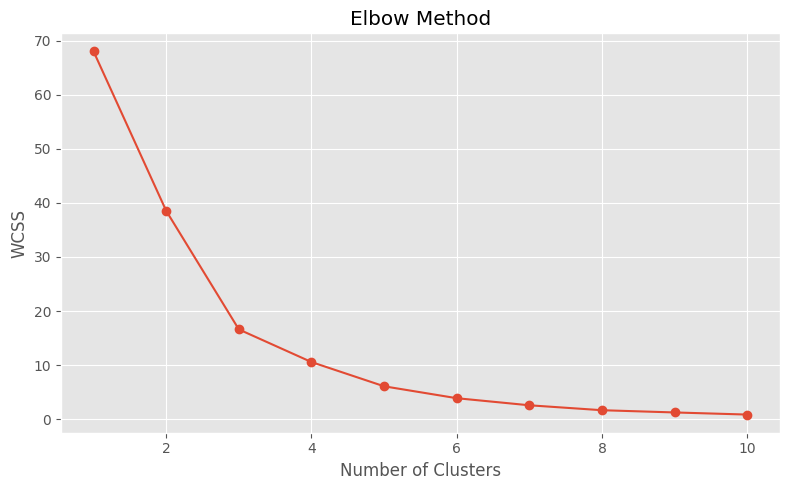

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "SalesForecasting_Mrinal/charts/elbow_method.png",
    dpi=300
)

plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_df["Cluster"] = kmeans.fit_predict(scaled)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

points = pca.fit_transform(scaled)

cluster_df["PC1"] = points[:,0]

cluster_df["PC2"] = points[:,1]

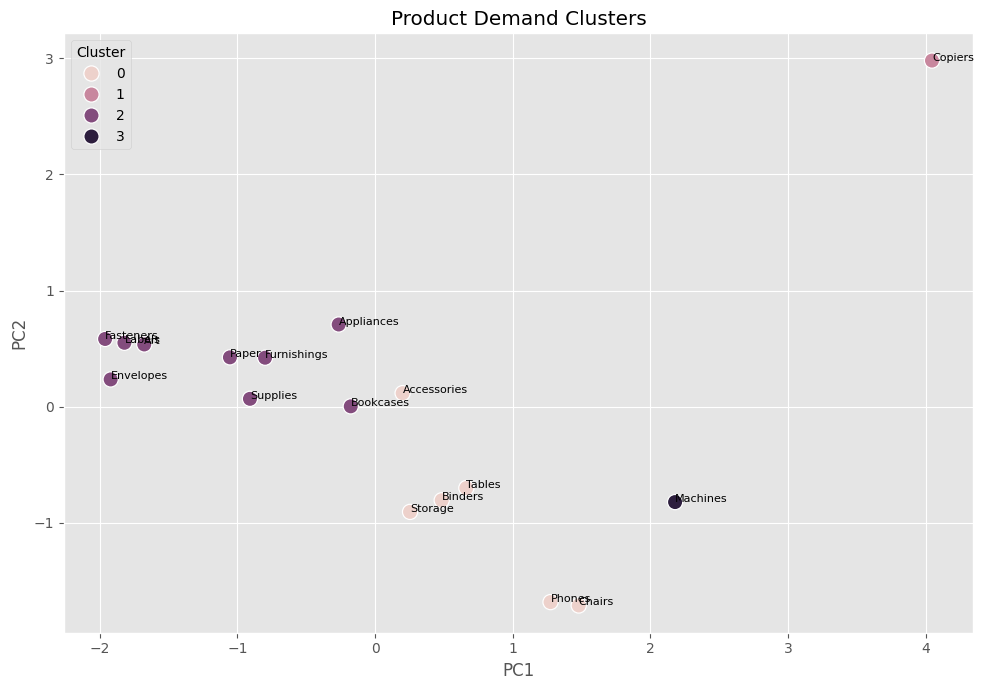

In [ ]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=cluster_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    s=120
)

for name, row in cluster_df.iterrows():

    plt.text(
        row["PC1"],
        row["PC2"],
        name,
        fontsize=8
    )

plt.title("Product Demand Clusters")

plt.tight_layout()

plt.savefig(
    "SalesForecasting_Mrinal/charts/product_clusters.png",
    dpi=300
)

plt.show()

In [ ]:
cluster_summary = (
    cluster_df
    .groupby("Cluster")
    .mean(numeric_only=True)
)

cluster_summary

,TotalSales,GrowthRate,Volatility,AverageOrderValue,PC1,PC2
Cluster,,,,,,
0,239495.780667,56.465168,3489.056075,361.131228,0.726087,-0.948011
1,146248.094000,479.729510,5500.774391,2215.880212,4.046026,2.979941
2,54341.708189,58.795823,1031.431565,142.746758,-1.175792,0.392146
3,189238.631000,-29.793120,5603.554747,1645.553313,2.179582,-0.821189


In [ ]:
cluster_df[
    ["Cluster"]
]

,Cluster
Sub-Category,
Accessories,0
Appliances,2
Art,2
Binders,0
Bookcases,2
Chairs,0
Copiers,1
Envelopes,2
Fasteners,2


In [ ]:
cluster_df.reset_index()[
    ["Sub-Category","Cluster"]
]

,Sub-Category,Cluster
0,Accessories,0
1,Appliances,2
2,Art,2
3,Binders,0
4,Bookcases,2
5,Chairs,0
6,Copiers,1
7,Envelopes,2
8,Fasteners,2
9,Furnishings,2
